In [16]:
import os
import random
import itertools
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [17]:
# ----------------------------
# 1. DATASET LOADING
# ----------------------------

class ImageDataset(Dataset):
    def __init__(self, root_celebA, root_monet, transform=None):
        self.celebA_images = sorted(os.listdir(root_celebA))
        self.monet_images = sorted(os.listdir(root_monet))
        self.celebA_root = root_celebA
        self.monet_root = root_monet
        self.transform = transform

    def __len__(self):
        return min(len(self.celebA_images), len(self.monet_images))

    def __getitem__(self, idx):
        img_celeb = Image.open(os.path.join(self.celebA_root, self.celebA_images[idx])).convert("RGB")
        img_monet = Image.open(os.path.join(self.monet_root, self.monet_images[idx])).convert("RGB")
        if self.transform:
            img_celeb = self.transform(img_celeb)
            img_monet = self.transform(img_monet)
        return {"A": img_celeb, "B": img_monet}




In [18]:
# ----------------------------
# 2. TRANSFORMS & DATALOADER
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = ImageDataset("dataset/celeba", "dataset/monet", transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)



In [19]:
# ----------------------------
# 3. MODELS
# ----------------------------
# ResNet-based Generator
class ResNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_residual_blocks=6):
        super().__init__()
        model = [
            nn.Conv2d(in_channels, 64, 7, 1, 3),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.InstanceNorm2d(256),
            nn.ReLU(inplace=True)
        ]

        for _ in range(num_residual_blocks):
            model += [ResidualBlock(256)]

        model += [
            nn.ConvTranspose2d(256, 128, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, out_channels, 7, 1, 3),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)

# PatchGAN Discriminator
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        model = [
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 1, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 1)
        ]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)



In [20]:
# ----------------------------
# 4. Instantiate Models
# ----------------------------
G_AB = ResNetGenerator().to(device)
G_BA = ResNetGenerator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)



In [21]:
# ----------------------------
# 5. Losses & Optimizers
# ----------------------------
criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

lr = 2e-4
beta1 = 0.5

optimizer_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr, betas=(beta1, 0.999))
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=lr, betas=(beta1, 0.999))



In [22]:
# ----------------------------
# 6. Training Loop
# ----------------------------
epochs = 5

for epoch in range(epochs):
    for i, batch in enumerate(tqdm(dataloader)):
        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)

        valid = torch.ones(real_A.size(0), 1, 14, 14).to(device)
        fake = torch.zeros(real_A.size(0), 1, 14, 14).to(device)

        # === Train Generators ===
        optimizer_G.zero_grad()

        fake_B = G_AB(real_A)
        loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)

        fake_A = G_BA(real_B)
        loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)

        recovered_A = G_BA(fake_B)
        recovered_B = G_AB(fake_A)

        loss_cycle_A = criterion_cycle(recovered_A, real_A)
        loss_cycle_B = criterion_cycle(recovered_B, real_B)

        loss_G = loss_GAN_AB + loss_GAN_BA + 10.0 * (loss_cycle_A + loss_cycle_B)
        loss_G.backward()
        optimizer_G.step()

        # === Train Discriminator A ===
        optimizer_D_A.zero_grad()
        loss_real = criterion_GAN(D_A(real_A), valid)
        loss_fake = criterion_GAN(D_A(fake_A.detach()), fake)
        loss_D_A = (loss_real + loss_fake) * 0.5
        loss_D_A.backward()
        optimizer_D_A.step()

        # === Train Discriminator B ===
        optimizer_D_B.zero_grad()
        loss_real = criterion_GAN(D_B(real_B), valid)
        loss_fake = criterion_GAN(D_B(fake_B.detach()), fake)
        loss_D_B = (loss_real + loss_fake) * 0.5
        loss_D_B.backward()
        optimizer_D_B.step()

    print(f"Epoch {epoch+1} | Loss_G: {loss_G.item():.4f} | Loss_D_A: {loss_D_A.item():.4f} | Loss_D_B: {loss_D_B.item():.4f}")



100%|██████████████████████████████████████████████████████████████████████████████| 1572/1572 [01:24<00:00, 18.54it/s]


Epoch 1 | Loss_G: 4.5789 | Loss_D_A: 0.1214 | Loss_D_B: 0.1439


100%|██████████████████████████████████████████████████████████████████████████████| 1572/1572 [01:24<00:00, 18.54it/s]


Epoch 2 | Loss_G: 4.1918 | Loss_D_A: 0.0846 | Loss_D_B: 0.2486


100%|██████████████████████████████████████████████████████████████████████████████| 1572/1572 [01:24<00:00, 18.55it/s]


Epoch 3 | Loss_G: 3.7734 | Loss_D_A: 0.1700 | Loss_D_B: 0.0945


100%|██████████████████████████████████████████████████████████████████████████████| 1572/1572 [01:25<00:00, 18.36it/s]


Epoch 4 | Loss_G: 4.7327 | Loss_D_A: 0.0725 | Loss_D_B: 0.2077


100%|██████████████████████████████████████████████████████████████████████████████| 1572/1572 [01:25<00:00, 18.38it/s]

Epoch 5 | Loss_G: 4.3237 | Loss_D_A: 0.1970 | Loss_D_B: 0.1813


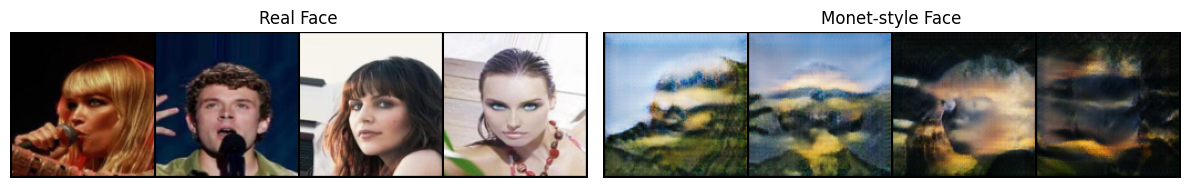

In [23]:
# ----------------------------
# 7. Visualization
# ----------------------------
def show_sample(real, fake, title1="Real", title2="Fake"):
    real = real[:4]
    fake = fake[:4]
    real = (real + 1) / 2
    fake = (fake + 1) / 2
    grid_real = make_grid(real, nrow=4)
    grid_fake = make_grid(fake, nrow=4)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(grid_real.permute(1, 2, 0).cpu().numpy())
    axs[0].set_title(title1)
    axs[0].axis("off")
    axs[1].imshow(grid_fake.permute(1, 2, 0).cpu().numpy())
    axs[1].set_title(title2)
    axs[1].axis("off")
    plt.tight_layout()
    plt.show()

# Show translation from CelebA → Monet
real_faces, real_paints = next(iter(dataloader))["A"].to(device), next(iter(dataloader))["B"].to(device)
with torch.no_grad():
    fake_paints = G_AB(real_faces)
    show_sample(real_faces, fake_paints, "Real Face", "Monet-style Face")
